262144


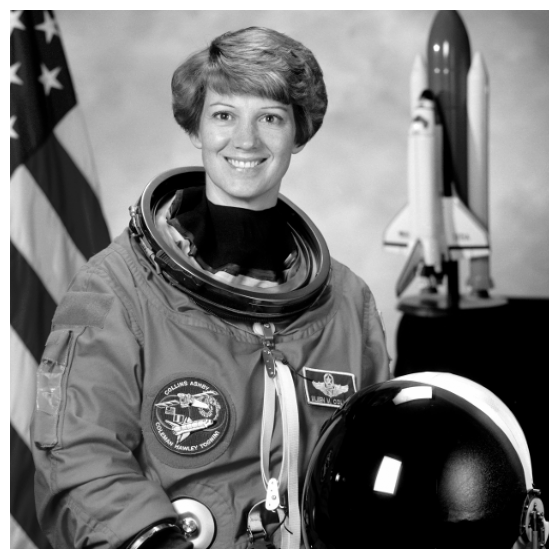

In [1]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from scipy.sparse.linalg import LinearOperator, eigsh
import scipy.optimize as so
from algorithms import Algorithms
import time
import pywt

img = sc.rgb2gray( si.data.astronaut() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [2]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

In [3]:
#testando se AT é adjunta de A ( y'Ax = x'ATy )

x = np.random.standard_normal( size = img.shape )
y = np.random.standard_normal( size = img.shape )

print( ( y * A( x ) ).sum() )
print( ( x * A_transpose( y ) ).sum() )

#okay

-43.01871986675533
-43.01871986675532


In [4]:
img_borrada = A( img )


In [5]:
#vendo se H é adjunta de HT (y'Hx = x'HTy) e se HT é a inversa de H

def H( x, wavelet = 'db5' ):
  return pywt.coeffs_to_array( pywt.wavedec2( x, wavelet = wavelet, mode = 'periodization' ) )

def HT( c, wavelet = 'db5' ):
  return pywt.waverec2( pywt.array_to_coeffs( *c, output_format = 'wavedec2' ), wavelet = wavelet, mode = 'periodization' )

Hx = H( x )

print( np.sum( y * Hx[ 0 ] ) )
print( np.sum( x * HT( ( y, Hx[ 1 ] ) ) ) )
print( np.abs( img - HT( H( img ) ) ).sum(  ) )
#para a imagem do café tem esse problema de que o pywt expande o tamanho da imagem, com isso H não é adjunta de HT ( encontrado o problema )
#para a imagem da astronauta tudo da certo

250.5691244168765
250.56912441687635
6.399910360449916e-11


In [6]:
#imagem borrada com ruído
gauss_noise = np.random.normal( 0, 0.01, img.shape )
b = img_borrada + gauss_noise

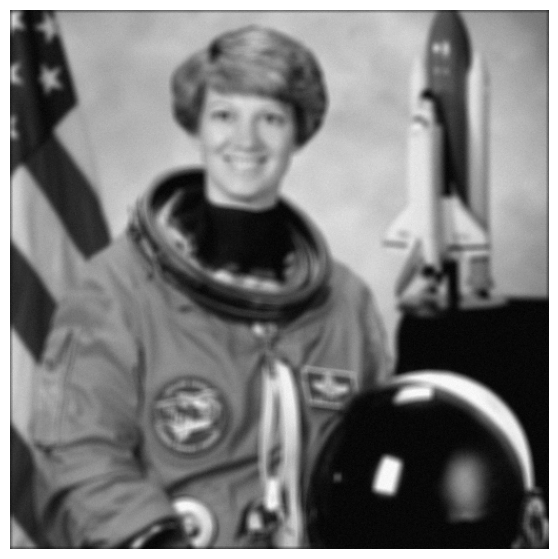

In [7]:
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [8]:
rows, cols = img_borrada.shape[ 0 ], img_borrada.shape[ 1 ]
dim = rows * cols

def mv( v ):
    x_2d = v.reshape( ( rows, cols ) )
    res_2d = ATA( x_2d )
    return res_2d.reshape( -1 )

operator = LinearOperator( ( dim, dim ), matvec = mv )

eigenvals, _ = eigsh( operator, k = 1, which = 'LM' )

norma_espectral = eigenvals[ 0 ]
print( f"Norma Espectral de A'A: {norma_espectral}" )
print( f'O tamanho de passo máximo para que o algoritmo seja garantido a convergir é de { 1 / norma_espectral }' )

Norma Espectral de A'A: 0.9997013347066693
O tamanho de passo máximo para que o algoritmo seja garantido a convergir é de 1.0002987545209372


In [9]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

def g( x, wavelet = 'db5' ):
  H_x, _ = H( x, wavelet )
  return np.sum( np.abs( H_x ) )

In [10]:
#usando o critério de quase-otimização ( qoc ) que encontrei no paper: Comparing parameter choice methods for regularization
#of ill-posed problems Frank Bauer a , Mark A. Lukas b

gammas = [ 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5 ] #os valores tem que estar ordenados
step = 1
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet
tol = 1.0e-10
max_iter = 100 

iters_gammas = []
for gamma in gammas:
    iters = Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav )
    iters_gammas.append( iters )

best_x_gamma = []
for iters in iters_gammas:
    best_x_gamma.append( iters[ -1 ] )

diffs_gamma = [ np.linalg.norm( best_x_gamma[ j ] - best_x_gamma[ j+1 ]) for j in range( len( best_x_gamma ) - 1 ) ]
j_star = np.argmin( diffs_gamma )
gamma_star = gammas[ j_star ]

print( "Gamma ótimo:", gamma_star )


Gamma ótimo: 0.01


In [11]:
def compare_methods( methods, f, g, grad_f, prox, x0, gamma, img, wav, ATA, max_iter = 1000, tol = 1e-2 ):
    results = {}
    for name, method in methods.items():

        start_time = time.perf_counter()
        iters = method( f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA )
        end_time = time.perf_counter()

        exec_time = end_time - start_time
        err_vals = [ np.abs( img - x ).sum() for x in iters ]
        F_vals = [ f( x ) + gamma * g( x, wav ) for x in iters ]

        results[ name ] = {
            "iterations": len( iters ),
            "execution_time": exec_time,
            "errors": err_vals,
            "F_values": F_vals,
            "final_image": iters[ -1 ]
        }

    F_star = min( min( vals[ "F_values" ] ) for vals in results.values() )
    return results, F_star

# Testando $\gamma = 0$ para ver se não há nenhum erro de implementação (algoritmos deveriam convergir)

In [12]:
step = 1
gamma = 0
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet

In [13]:
methods = {
    "ISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.ista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.ista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_backtracking( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, beta = 0.95, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav  )
}


results, F_star = compare_methods( methods = methods, f = f, g = g, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, img = img, wav = wav, ATA = ATA, max_iter = 250, tol = 1e-2 )
#mesmo com a A sendo adjunta a AT, H adjunta a HT e HT sendo a inversa de H, o fista utilizando o passo exato não converge


O tamanho do passo para o ista com passo exato foi de: 1.0136816896835814
O tamanho do passo para o ista com passo exato foi de: 2.0612906419784784
O tamanho do passo para o ista com passo exato foi de: 2.069080663245005
O tamanho do passo para o ista com passo exato foi de: 2.071051450327569
O tamanho do passo para o ista com passo exato foi de: 2.071847912894747
O tamanho do passo para o fista com passo exato foi de: 1.0136816896835814
O tamanho do passo para o fista com passo exato foi de: 1.3388974464471182
O tamanho do passo para o fista com passo exato foi de: 1.3353133842239615
O tamanho do passo para o fista com passo exato foi de: 1.3345730300387324
O tamanho do passo para o fista com passo exato foi de: 1.3345212734023102


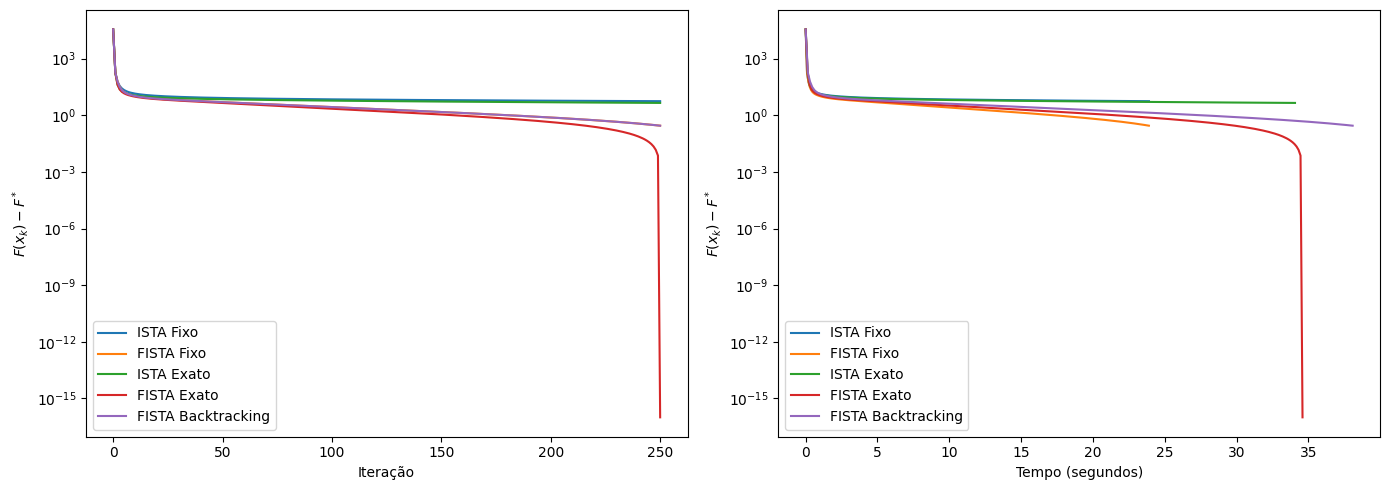

In [14]:
epsilon = 1e-16
names = [ "ISTA Fixo", "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "F_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()


plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "F_values" ] )
    diff_vals = vals - F_star + epsilon
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()


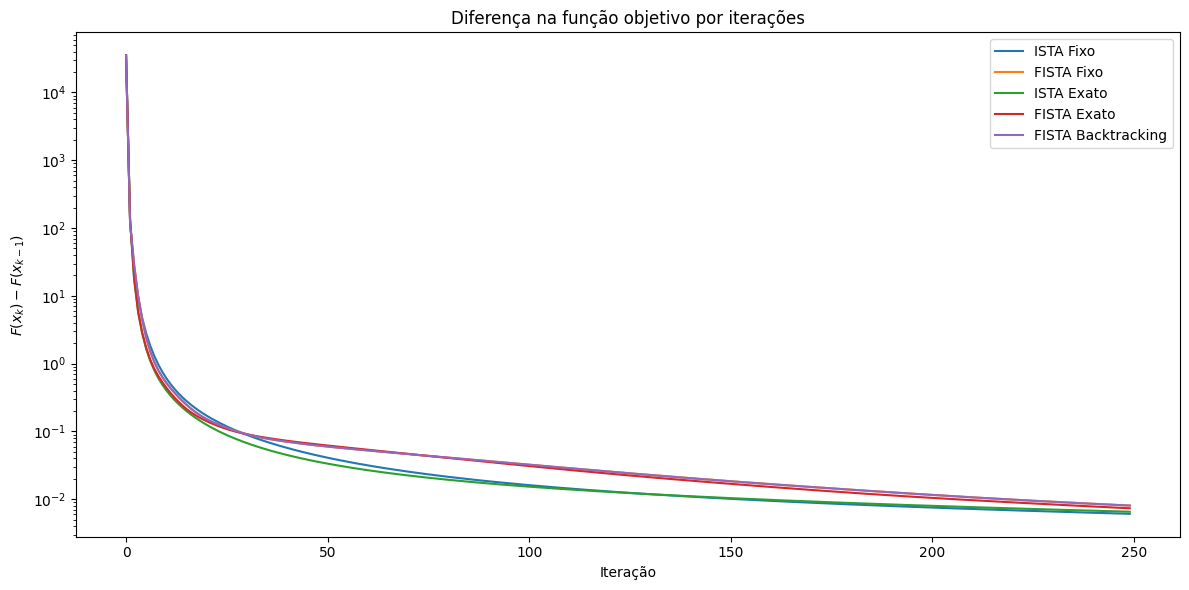

In [15]:
def delta_F( F_vals ):
    return [ abs( F_vals[ k ] - F_vals[ k-1 ] ) for k in range( 1, len( F_vals ) ) ]

plt.figure( figsize = ( 12, 6 ) )
for name in names:
    deltas = delta_F( results[ name ][ "F_values" ] )
    plt.semilogy( deltas, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F(x_{k-1})$" )
plt.title("Diferença na função objetivo por iterações")
plt.tight_layout()
plt.show()

Note que todos convergem, logo a implementação parece estar correta

# Testando para o $\gamma = 0.01$ ótimo

In [16]:
step = 1
gamma = gamma_star
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet

In [17]:
methods = {
    "ISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.ista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.ista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_backtracking( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, beta = 0.95, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav  )
}


results, F_star = compare_methods( methods = methods, f = f, g = g, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, img = img, wav = wav, ATA = ATA, max_iter = 250, tol = 1e-2 )
#mesmo com a A sendo adjunta a AT, H adjunta a HT e HT sendo a inversa de H, o fista utilizando o passo exato não converge


O tamanho do passo para o ista com passo exato foi de: 1.0136816896835814
O tamanho do passo para o ista com passo exato foi de: 1.7133930242291748
O tamanho do passo para o ista com passo exato foi de: 1.714505931029835
O tamanho do passo para o ista com passo exato foi de: 1.716170778045908
O tamanho do passo para o ista com passo exato foi de: 1.7177444210410382
O tamanho do passo para o fista com passo exato foi de: 1.0136816896835814
O tamanho do passo para o fista com passo exato foi de: 1.2656501430011142
O tamanho do passo para o fista com passo exato foi de: 1.2623528409919051
O tamanho do passo para o fista com passo exato foi de: 1.2616766070886352
O tamanho do passo para o fista com passo exato foi de: 1.261606917204821


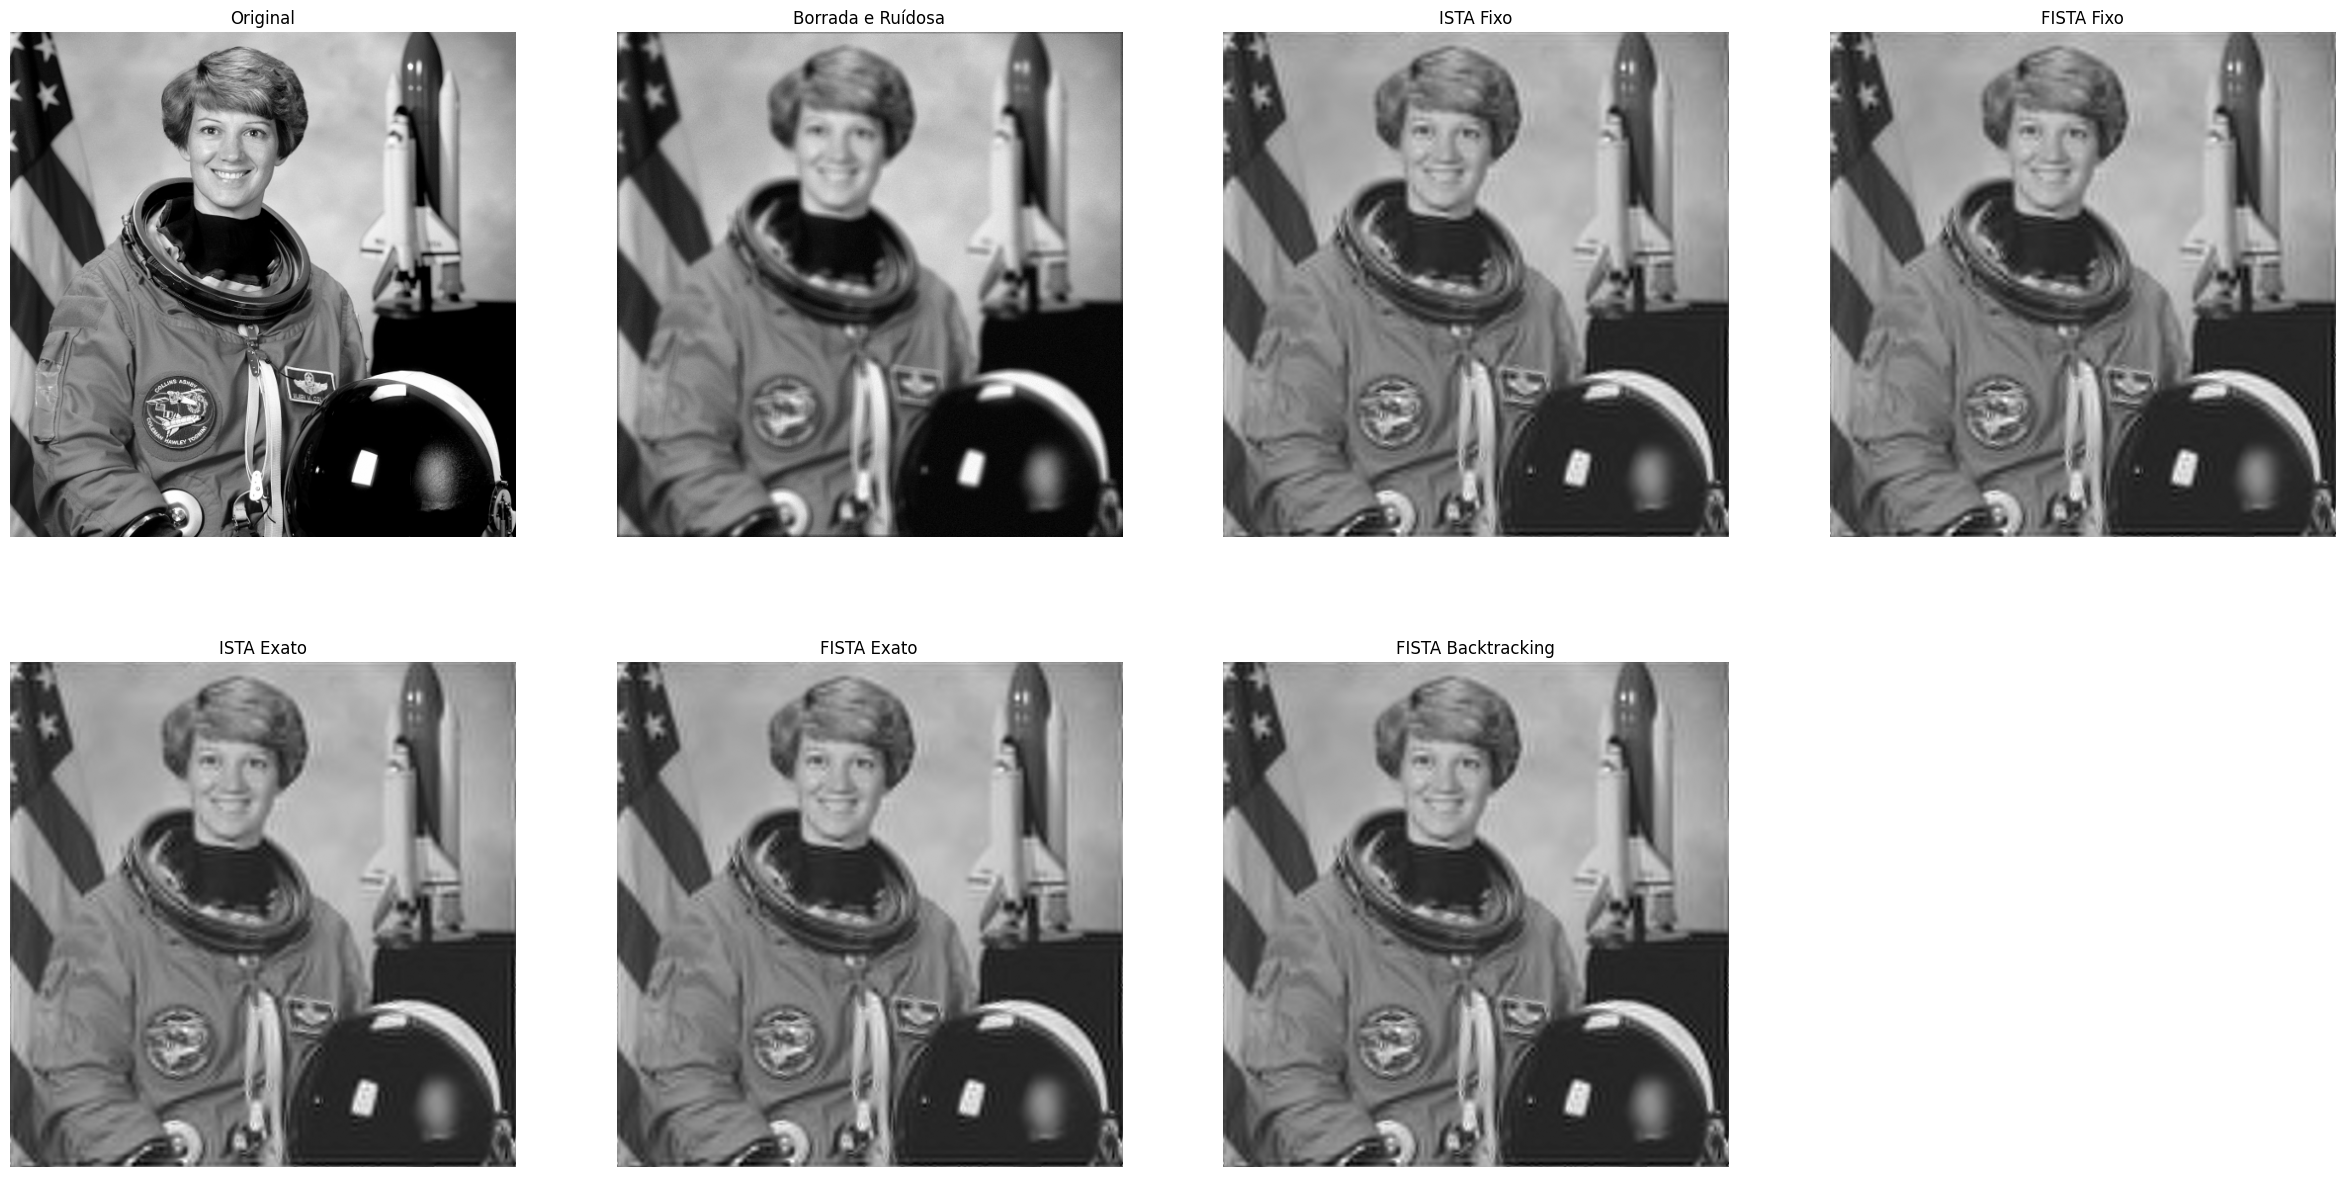

In [22]:
plt.figure( figsize = ( 30, 15 ) )

names = [ "ISTA Fixo", "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 2, 4, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada e Ruídosa" )

for i, name in enumerate( names, start = 3 ):
    plt.subplot( 2, 4, i )
    plt.imshow( results[ name ][ "final_image" ], cmap = plt.cm.gray )
    plt.axis( "off" )
    plt.title( name )

plt.show()


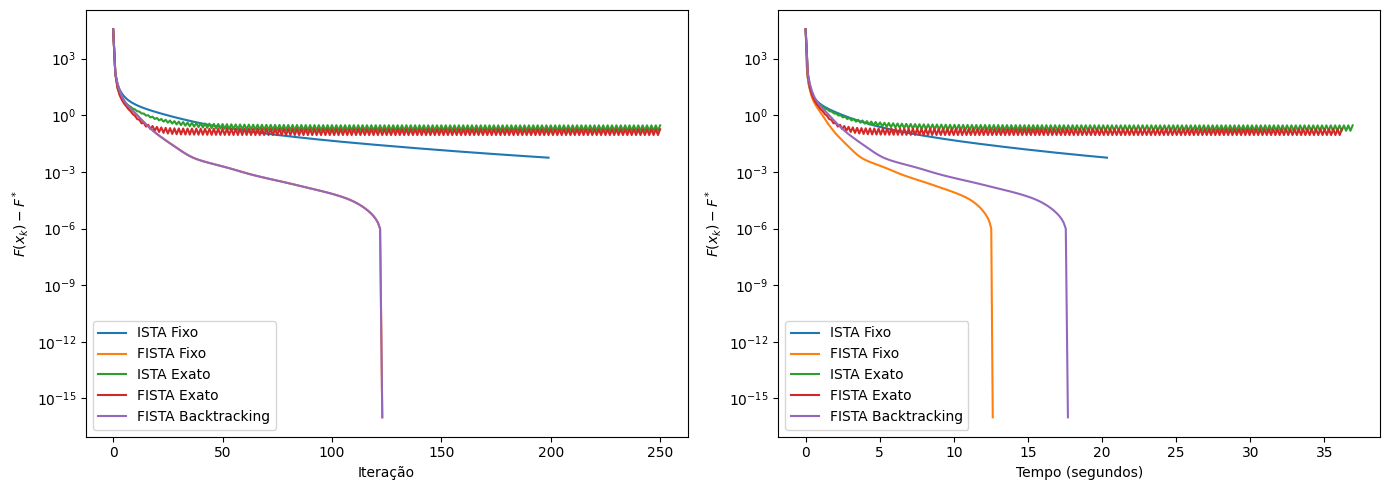

In [23]:
epsilon = 1e-16

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "F_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()


plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "F_values" ] )
    diff_vals = vals - F_star + epsilon
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()


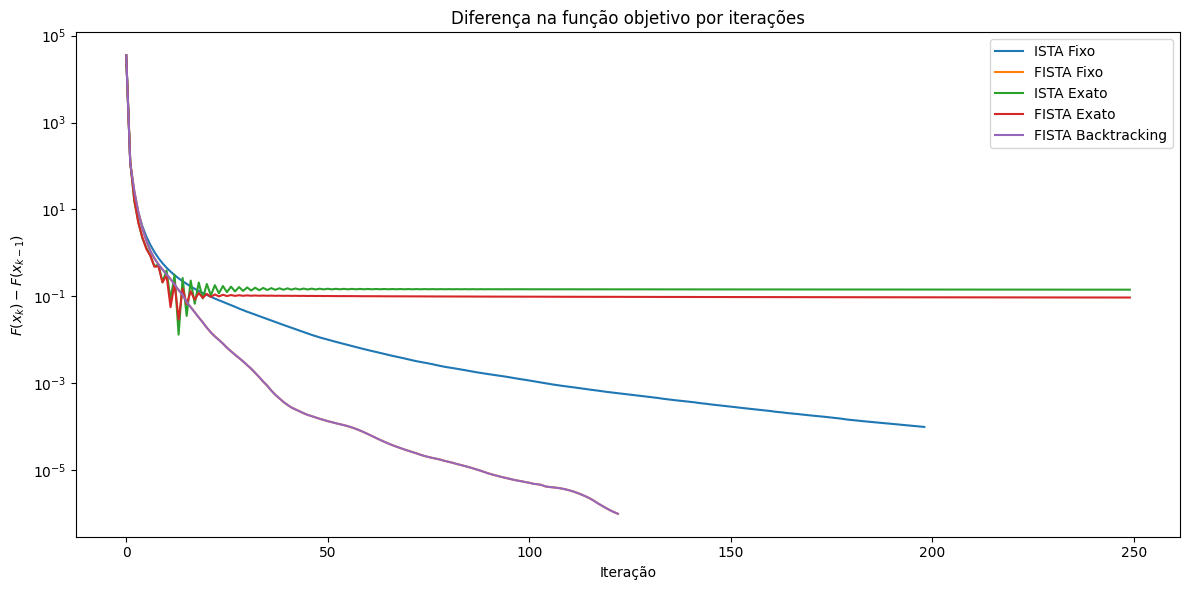

In [24]:
def delta_F( F_vals ):
    return [ abs( F_vals[ k ] - F_vals[ k-1 ] ) for k in range( 1, len( F_vals ) ) ]

plt.figure( figsize = ( 12, 6 ) )
for name in names:
    deltas = delta_F( results[ name ][ "F_values" ] )
    plt.semilogy( deltas, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F(x_{k-1})$" )
plt.title("Diferença na função objetivo por iterações")
plt.tight_layout()
plt.show()

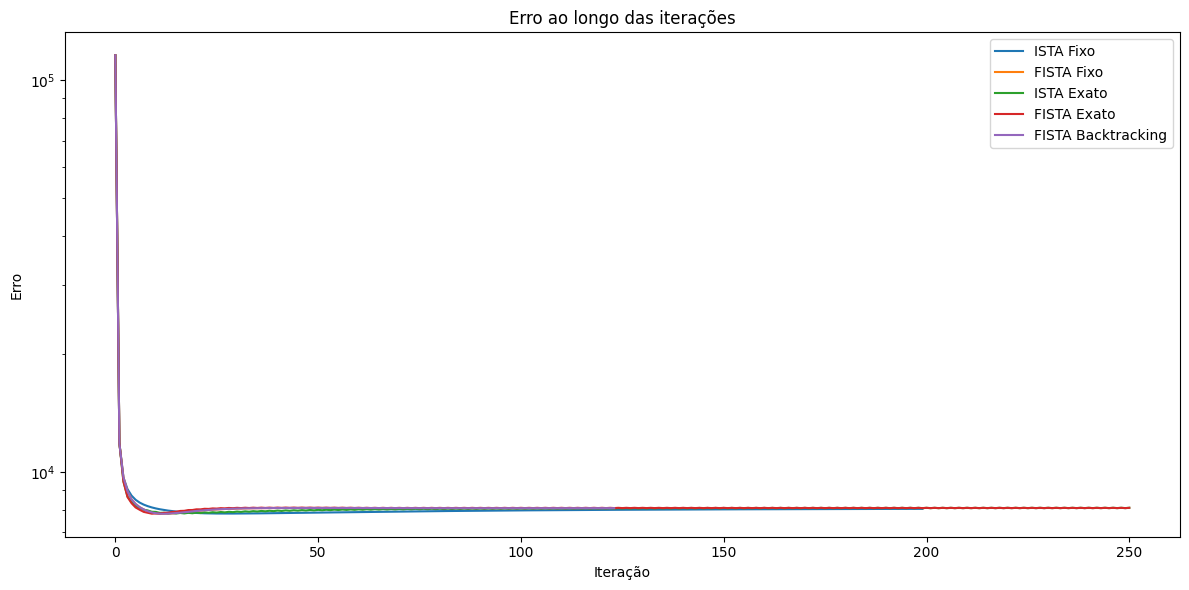

In [25]:
plt.figure( figsize = ( 12, 6 ) )

for name in names:
    vals = results[ name ][ "errors" ]
    plt.semilogy( vals, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "Erro" )
plt.title( "Erro ao longo das iterações" )
plt.tight_layout()
plt.show()


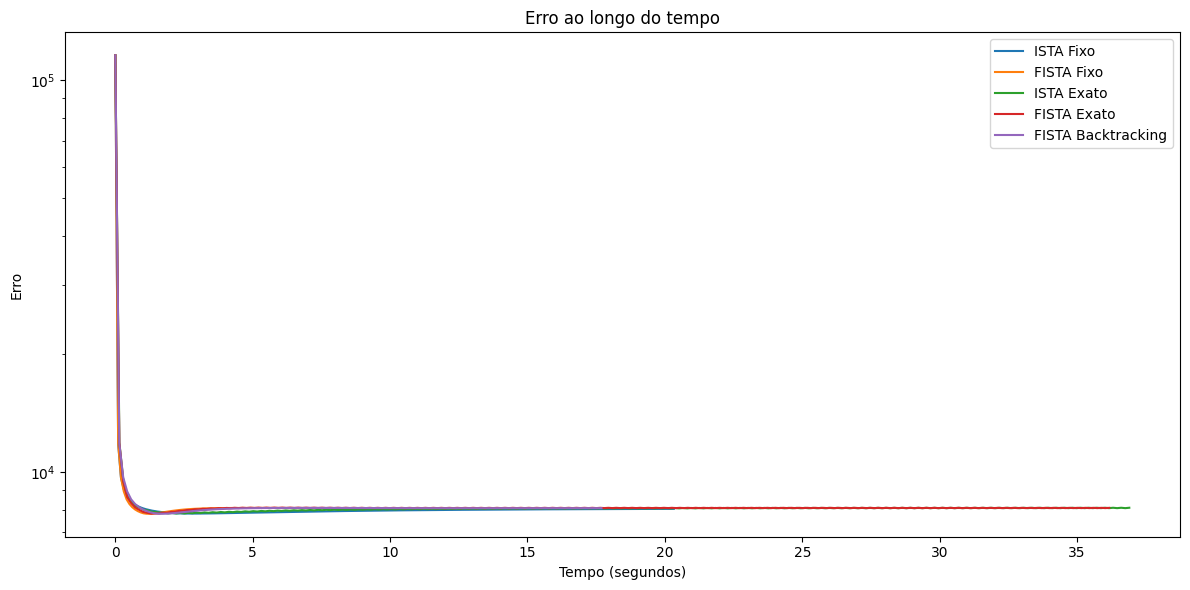

In [26]:
plt.figure( figsize = ( 12, 6 ) )

for name in names:
    vals = np.array( results[ name ][ "errors" ] )
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Erro" )
plt.legend()
plt.title( "Erro ao longo do tempo" )
plt.tight_layout()
plt.show()


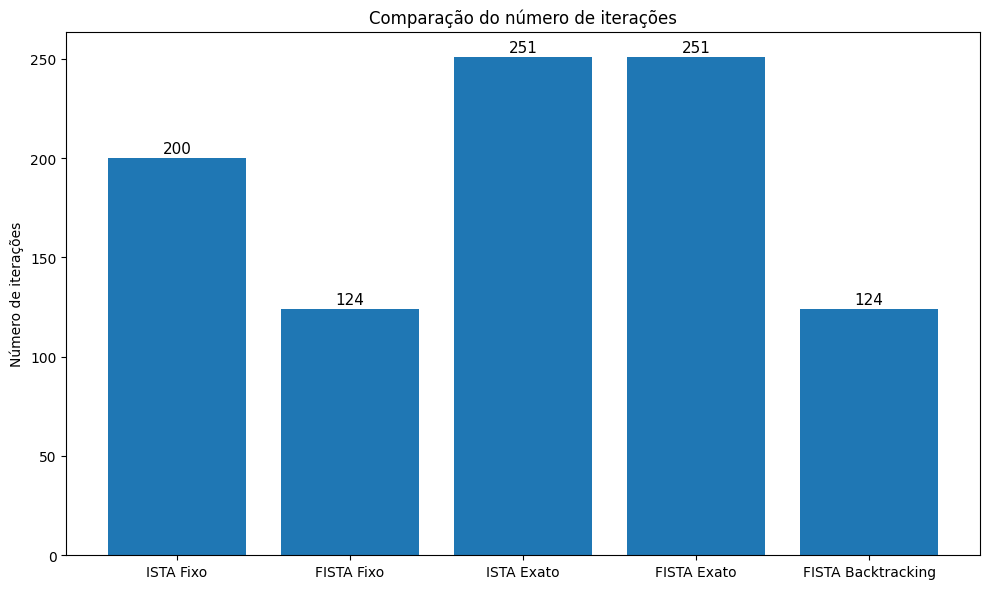

In [27]:
num_iters = [ results[ name ][ "iterations" ] for name in names ]

plt.figure( figsize = ( 10, 6 ) )
bars = plt.bar( names, num_iters )
plt.ylabel( "Número de iterações" )
plt.title( "Comparação do número de iterações" )

for bar in bars:
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width() / 2, height + 1, str( height ), ha = 'center', va = 'bottom', fontsize = 11 )
plt.tight_layout()
plt.show()


# Testando para valores maiores de $\gamma$

In [28]:
step = 1
gamma = 0.2
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet

In [29]:
methods = {
    "ISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.ista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.ista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav ),
    "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, wav, ATA: Algorithms.fista_backtracking( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, beta = 0.95, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav  )

}


results, F_star = compare_methods( methods = methods, f = f, g = g, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, img = img, wav = wav, ATA = ATA, max_iter = 250, tol = 1e-2 )
#mesmo com a A sendo adjunta a AT, H adjunta a HT e HT sendo a inversa de H, o fista utilizando o passo exato não converge


O tamanho do passo para o ista com passo exato foi de: 1.0136816896835814
O tamanho do passo para o fista com passo exato foi de: 1.0136816896835814
O tamanho do passo para o fista com passo exato foi de: 1.246637828327772
O tamanho do passo para o fista com passo exato foi de: 1.2418399686472303
O tamanho do passo para o fista com passo exato foi de: 1.240913318781204
O tamanho do passo para o fista com passo exato foi de: 1.2408383866275796


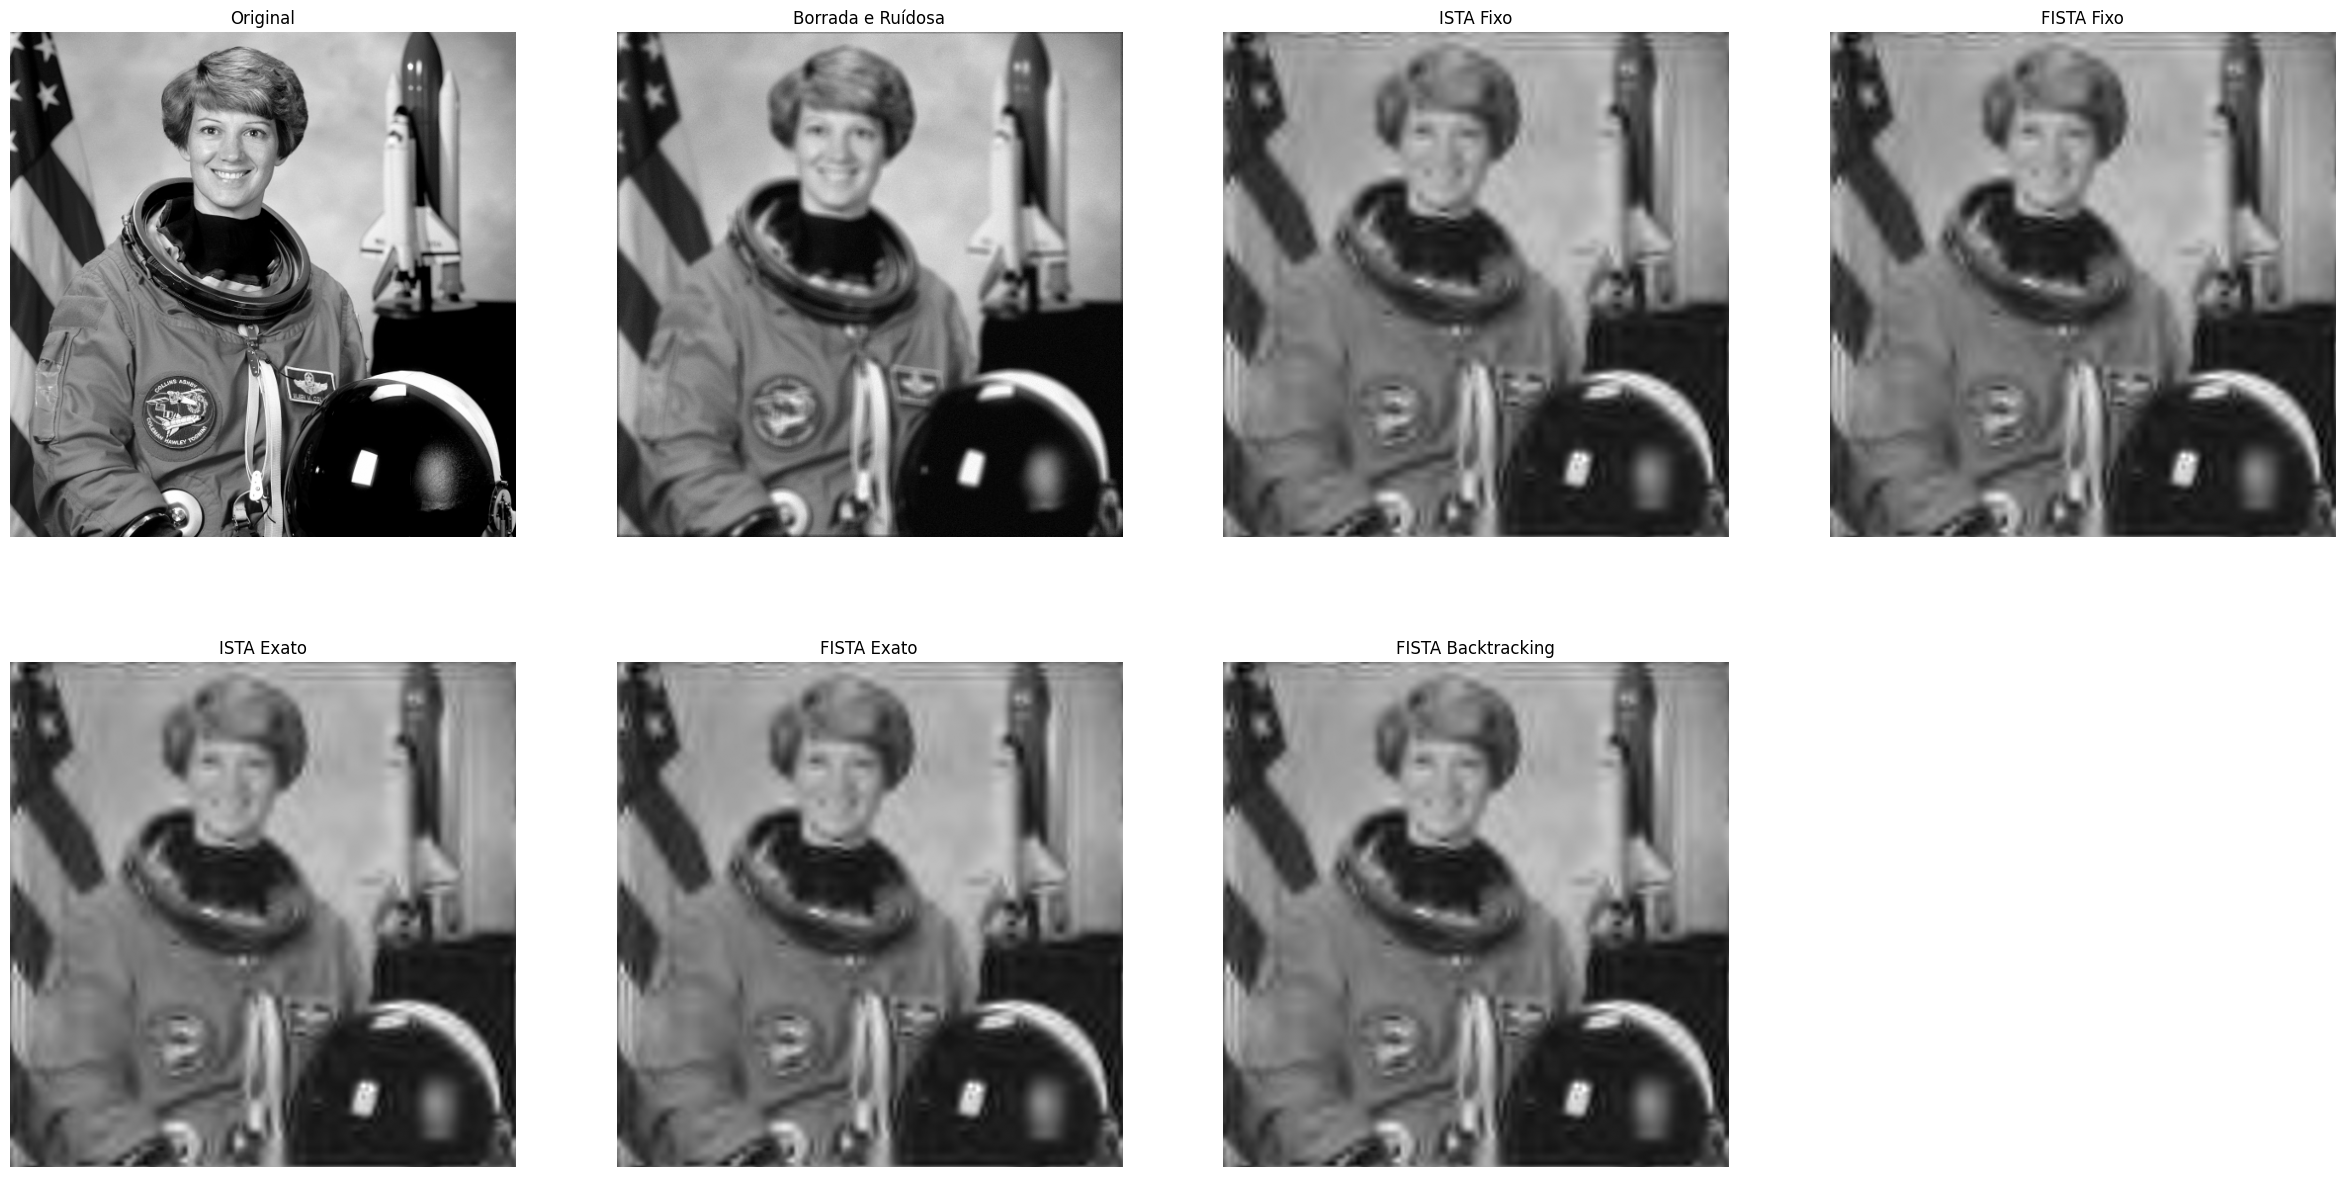

In [30]:
plt.figure( figsize = ( 30, 15 ) )

names = [ "ISTA Fixo", "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 2, 4, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada e Ruídosa" )

for i, name in enumerate( names, start = 3 ):
    plt.subplot( 2, 4, i )
    plt.imshow( results[ name ][ "final_image" ], cmap = plt.cm.gray )
    plt.axis( "off" )
    plt.title( name )

plt.show()


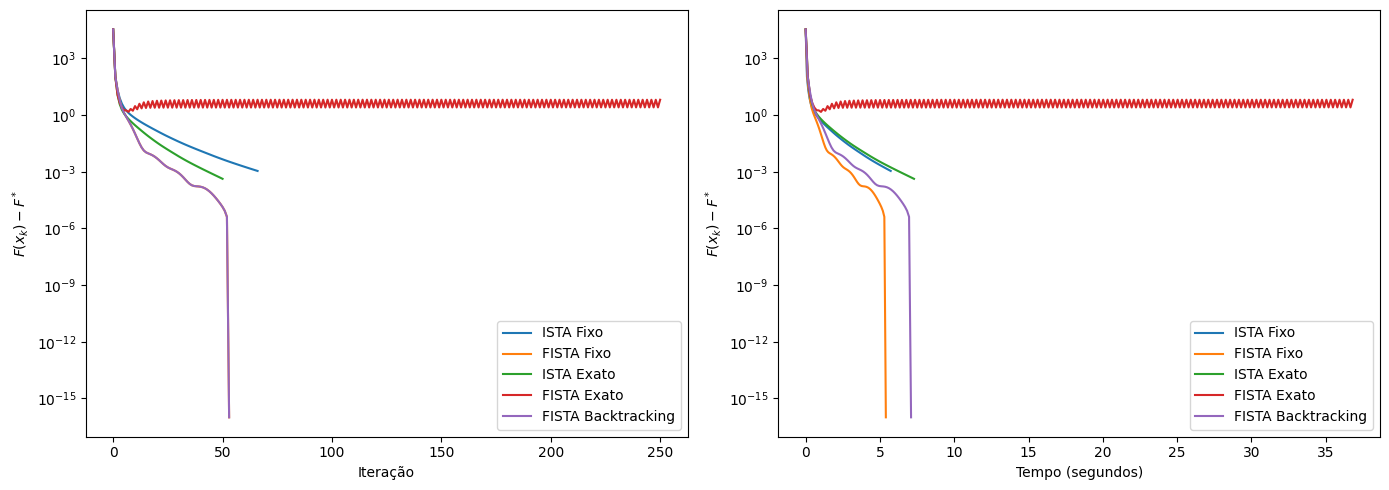

In [31]:
epsilon = 1e-16

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "F_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()


plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "F_values" ] )
    diff_vals = vals - F_star + epsilon
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()


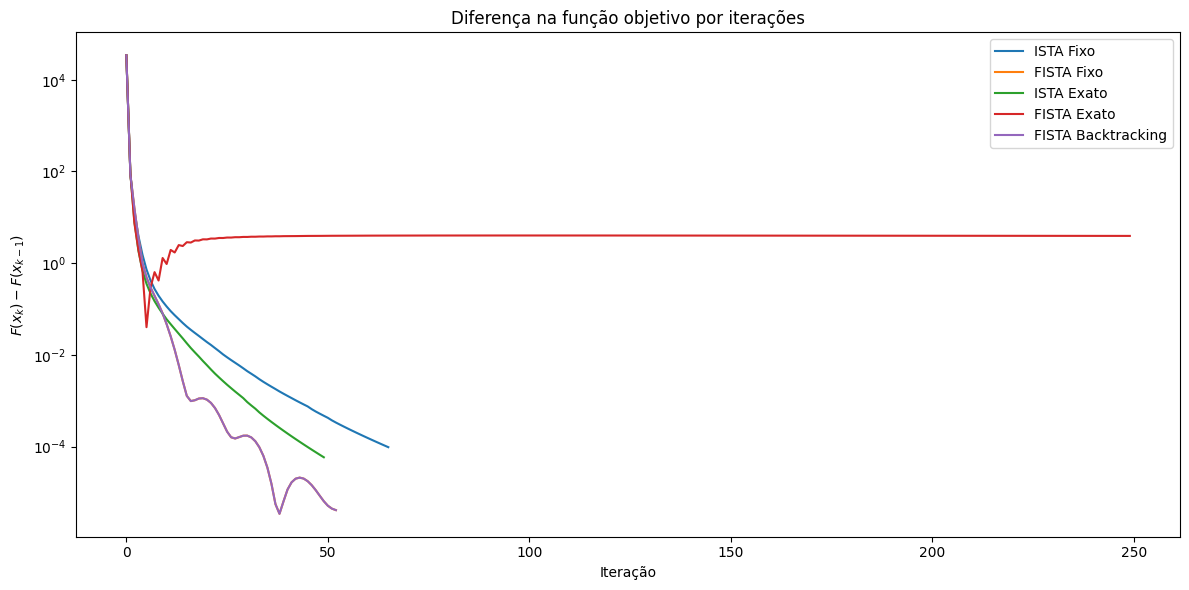

In [32]:
def delta_F( F_vals ):
    return [ abs( F_vals[ k ] - F_vals[ k-1 ] ) for k in range( 1, len( F_vals ) ) ]

plt.figure( figsize = ( 12, 6 ) )
for name in names:
    deltas = delta_F( results[ name ][ "F_values" ] )
    plt.semilogy( deltas, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F(x_{k-1})$" )
plt.title("Diferença na função objetivo por iterações")
plt.tight_layout()
plt.show()

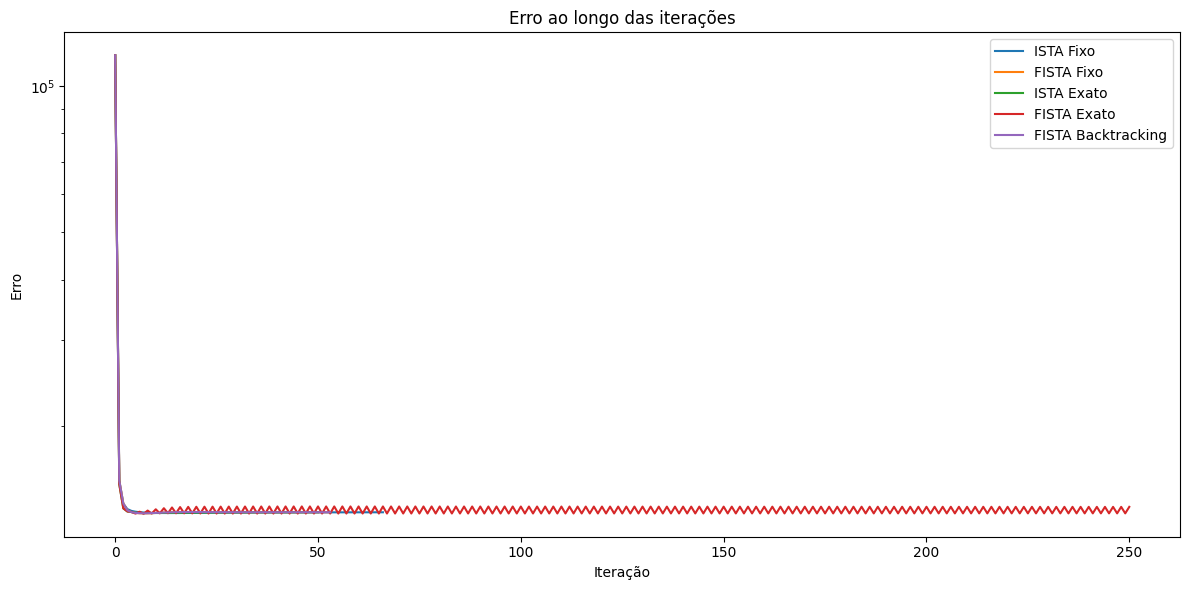

In [33]:
plt.figure( figsize = ( 12, 6 ) )

for name in names:
    vals = results[ name ][ "errors" ]
    plt.semilogy( vals, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "Erro" )
plt.title( "Erro ao longo das iterações" )
plt.tight_layout()
plt.show()


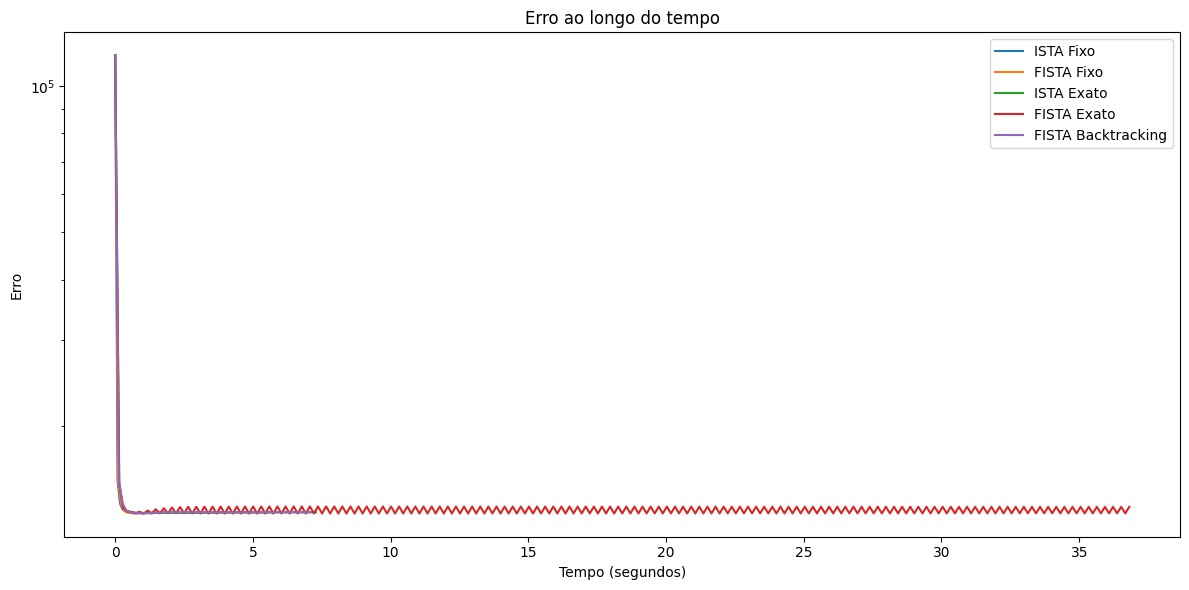

In [34]:
plt.figure( figsize = ( 12, 6 ) )

for name in names:
    vals = np.array( results[ name ][ "errors" ] )
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Erro" )
plt.legend()
plt.title( "Erro ao longo do tempo" )
plt.tight_layout()
plt.show()


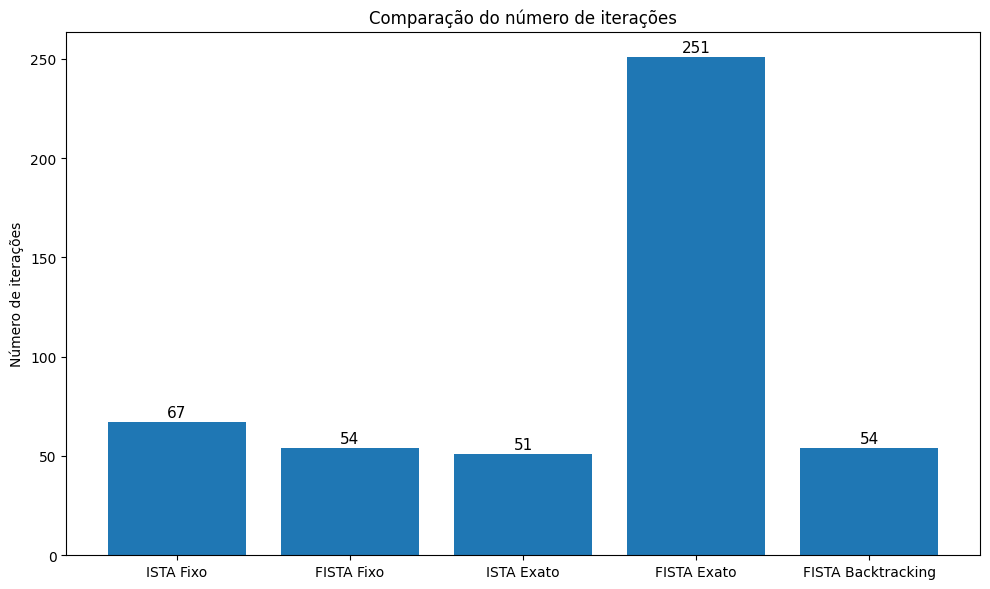

In [35]:
num_iters = [ results[ name ][ "iterations" ] for name in names ]

plt.figure( figsize = ( 10, 6 ) )
bars = plt.bar( names, num_iters )
plt.ylabel( "Número de iterações" )
plt.title( "Comparação do número de iterações" )

for bar in bars:
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width() / 2, height + 1, str( height ), ha = 'center', va = 'bottom', fontsize = 11 )
plt.tight_layout()
plt.show()


Note que parece que para valores pequenos de $\gamma$ o algoritmo não converge para o ISTA Exato (porque?). Para valores maiores do parâmentro de regularização o algoritmo parece convergir.

Importante notar também como a qualidade da reconstrução para o valor de parâmetro de regularização $\gamma = 0.01$ é muito melhor do que para $\gamma = 0.2$.

Além disso, para o FISTA Exato, o algoritmo não parece convergir para nenhum valor de $\gamma$